In [71]:
import pandas as pd
import statsmodels.api as sm
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_csv("CarPrice_Assignment.csv")

In [73]:
df.select_dtypes("object").nunique()

/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_65411/3517814742.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes("object").nunique()


CarName           147
fueltype            2
aspiration          2
doornumber          2
carbody             5
drivewheel          3
enginelocation      2
enginetype          7
cylindernumber      7
fuelsystem          8
dtype: int64

In [74]:
for i in df.select_dtypes("object").columns:
    print(i)
    print(df[i].unique())
    print()

CarName
<StringArray>
[      'alfa-romero giulia',      'alfa-romero stelvio',
 'alfa-romero Quadrifoglio',              'audi 100 ls',
               'audi 100ls',                 'audi fox',
                'audi 5000',                'audi 4000',
      'audi 5000s (diesel)',                 'bmw 320i',
 ...
                'vw rabbit',        'volkswagen rabbit',
 'volkswagen rabbit custom',          'volvo 145e (sw)',
              'volvo 144ea',              'volvo 244dl',
                'volvo 245',              'volvo 264gl',
             'volvo diesel',                'volvo 246']
Length: 147, dtype: str

fueltype
<StringArray>
['gas', 'diesel']
Length: 2, dtype: str

aspiration
<StringArray>
['std', 'turbo']
Length: 2, dtype: str

doornumber
<StringArray>
['two', 'four']
Length: 2, dtype: str

carbody
<StringArray>
['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop']
Length: 5, dtype: str

drivewheel
<StringArray>
['rwd', 'fwd', '4wd']
Length: 3, dtype: str

enginelocati

/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_65411/3894164883.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i in df.select_dtypes("object").columns:


In [75]:
df.cylindernumber.value_counts()

cylindernumber
four      159
six        24
five       11
eight       5
two         4
three       1
twelve      1
Name: count, dtype: int64

In [76]:
df["cylindernumber"] = df.cylindernumber.map({"two":2,"four":4,"six":6,"eight":8,"twelve":12,"five":5,"three":3})

In [77]:
df.cylindernumber

0      4
1      4
2      6
3      4
4      5
      ..
200    4
201    4
202    6
203    6
204    4
Name: cylindernumber, Length: 205, dtype: int64

In [78]:
df.doornumber = df.doornumber.map({"two": 2, "four": 4})

In [79]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,2,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,2,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,2,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,4,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,4,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [80]:
df["carbody"].value_counts()


carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

In [81]:
df = pd.get_dummies(data = df, columns=["fueltype","aspiration","carbody","enginelocation","drivewheel"], drop_first = True)


In [82]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_ID               205 non-null    int64  
 1   symboling            205 non-null    int64  
 2   CarName              205 non-null    str    
 3   doornumber           205 non-null    int64  
 4   wheelbase            205 non-null    float64
 5   carlength            205 non-null    float64
 6   carwidth             205 non-null    float64
 7   carheight            205 non-null    float64
 8   curbweight           205 non-null    int64  
 9   enginetype           205 non-null    str    
 10  cylindernumber       205 non-null    int64  
 11  enginesize           205 non-null    int64  
 12  fuelsystem           205 non-null    str    
 13  boreratio            205 non-null    float64
 14  stroke               205 non-null    float64
 15  compressionratio     205 non-null    float64
 16  h

In [83]:
df.drop("car_ID", axis=1, inplace=True)

In [84]:
df.drop("CarName", axis=1, inplace=True)


# EDA

In [85]:
df.select_dtypes(include='number').corr()["price"].sort_values(key= abs, ascending=False)[1:]

enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
cylindernumber      0.718305
highwaympg         -0.697599
citympg            -0.685751
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
peakrpm            -0.085267
symboling          -0.079978
stroke              0.079443
compressionratio    0.067984
doornumber          0.031835
Name: price, dtype: float64

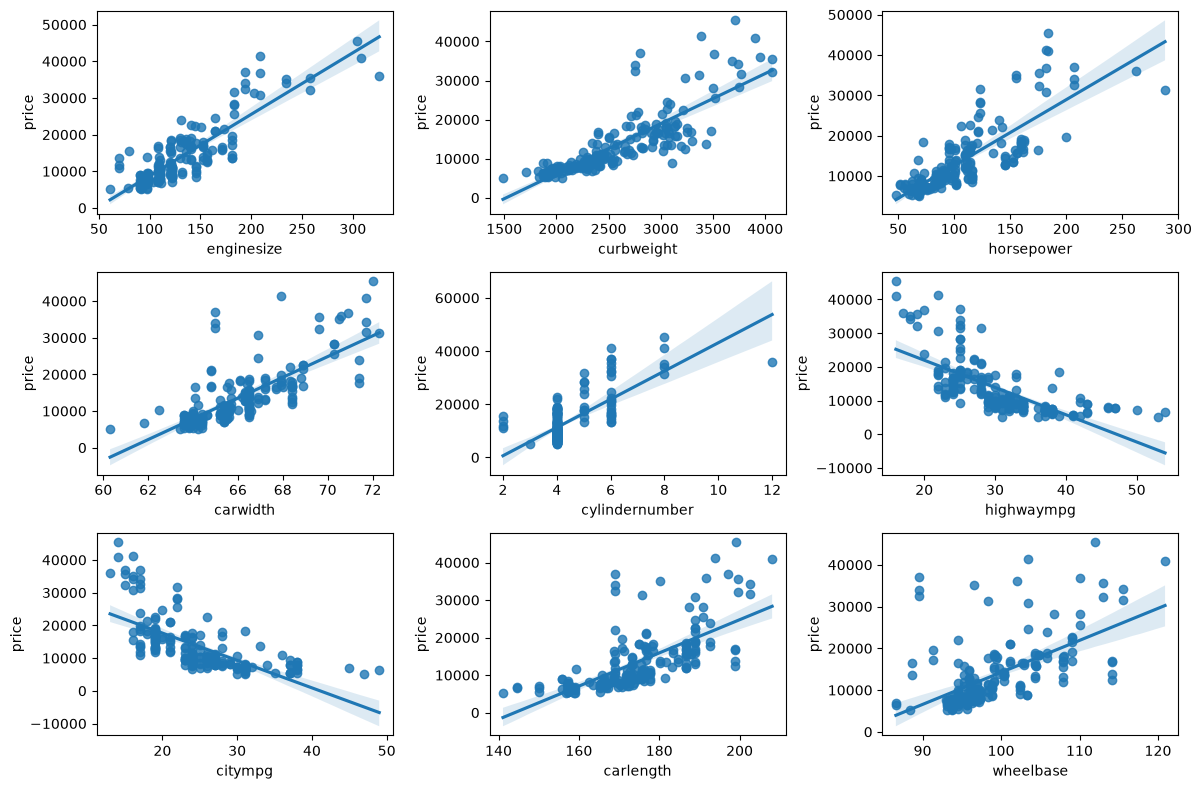

In [86]:
fig, ax = plt.subplots(3,3, figsize=(12,8))

sns.regplot(x='enginesize', y='price', data=df, ax=ax[0][0])
sns.regplot(x='curbweight', y='price', data=df, ax=ax[0][1])
sns.regplot(x='horsepower', y='price', data=df, ax=ax[0][2])
sns.regplot(x='carwidth', y='price', data=df, ax=ax[1][0])
sns.regplot(x='cylindernumber', y='price', data=df, ax=ax[1][1])
sns.regplot(x='highwaympg', y='price', data=df, ax=ax[1][2])
sns.regplot(x='citympg', y='price', data=df, ax=ax[2][0])
sns.regplot(x='carlength', y='price', data=df, ax=ax[2][1])
sns.regplot(x='wheelbase', y='price', data=df, ax=ax[2][2])

plt.tight_layout()

# Independent cariable split and dependent variable split

## split data into `X` and `y` 

In [87]:
X = df.select_dtypes("number").drop("price",axis=1)
y = df.price

In [88]:
zlist = [col for col in X.columns if X[col].nunique()>2]

In [89]:
from scipy.stats import zscore

In [90]:
scaled = X[zlist].apply(zscore)

In [91]:
dummies = df.select_dtypes(include=bool)

In [92]:
dummies

,fueltype_gas,aspiration_turbo,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,enginelocation_rear,drivewheel_fwd,drivewheel_rwd
0,True,False,False,False,False,False,False,False,True
1,True,False,False,False,False,False,False,False,True
2,True,False,False,True,False,False,False,False,True
3,True,False,False,False,True,False,False,True,False
4,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...
200,True,False,False,False,True,False,False,False,True
201,True,True,False,False,True,False,False,False,True
202,True,False,False,False,True,False,False,False,True
203,False,True,False,False,True,False,False,False,True


In [93]:
dummies = dummies.astype(int)

In [94]:
dummies

,fueltype_gas,aspiration_turbo,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,enginelocation_rear,drivewheel_fwd,drivewheel_rwd
0,1,0,0,0,0,0,0,0,1
1,1,0,0,0,0,0,0,0,1
2,1,0,0,1,0,0,0,0,1
3,1,0,0,0,1,0,0,1,0
4,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...
200,1,0,0,0,1,0,0,0,1
201,1,1,0,0,1,0,0,0,1
202,1,0,0,0,1,0,0,0,1
203,0,1,0,0,1,0,0,0,1


In [95]:
binary = X[[col for col in X.columns if X[col].nunique() <= 2]]
binary

,doornumber
0,2
1,2
2,2
3,4
4,4
...,...
200,4
201,4
202,4
203,4


In [96]:
X = pd.concat([scaled,dummies,binary], axis=1)

In [97]:
X.head()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,...,fueltype_gas,aspiration_turbo,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,enginelocation_rear,drivewheel_fwd,drivewheel_rwd,doornumber
0,1.743470,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,-0.352887,0.074449,0.519071,-1.839377,...,1,0,0,0,0,0,0,0,1,2
1,1.743470,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,-0.352887,0.074449,0.519071,-1.839377,...,1,0,0,0,0,0,0,0,1,2
2,0.133509,-0.708596,-0.231513,-0.190566,-0.543527,0.514882,1.502032,0.604046,-2.404880,0.685946,...,1,0,0,1,0,0,0,0,1,2
3,0.938490,0.173698,0.207256,0.136542,0.235942,-0.420797,-0.352887,-0.431076,-0.517266,0.462183,...,1,0,0,0,1,0,0,1,0,4
4,0.938490,0.107110,0.207256,0.230001,0.235942,0.516807,0.574572,0.218885,-0.517266,0.462183,...,1,0,0,0,1,0,0,0,0,4


## RFE | Preprocessing Step to Find the Best Estimators/Features
Recursive feature elimination (RFE) is a feature selection technique used in machine learning and statistics to select the most important features for a predictive model. RFE works by recursively removing features from the model and building a new model with the remaining features, until a specified number of features are left. It is a wrapper method, meaning that it uses a specific model (e.g. linear regression, support vector machines, etc.) to determine which features to eliminate.
The general steps for performing RFE are as follows:

**1. Choose a model: First, you need to choose a model that you want to use to perform feature selection. Common models used for RFE include linear regression, logistic regression, and support vector machines.**

**2. Specify the number of features: Next, you need to specify the number of features you want to end up with at the end of the feature selection process. This can be a fixed number or a percentage of the original features.**

**3. Eliminate the least important feature: The model is trained on the original set of features, and the importance of each feature is determined by examining the model's coefficients or weights. The least important feature is then eliminated from the set of features.**

**4. Build a new model: A new model is built using the remaining features, and steps 3 and 4 are repeated until the desired number of features is reached.**

**5. Evaluate the model: Finally, the model is evaluated using a validation set or cross-validation to assess the performance of the selected features.**

RFE can be a powerful feature selection technique, as it can help to improve the performance and interpretability of a model by selecting the most important features. However, it can be computationally intensive, especially when dealing with large numbers of features or complex models. It is also important to keep in mind that feature selection is not a panacea, and that it is always possible to select a suboptimal set of features. Therefore, it is always a good practice to combine feature selection with other techniques such as regularization and cross-validation to avoid overfitting and ensure robustness of the model.


In [98]:
estimator = LinearRegression()

In [103]:
rfe = RFE(estimator, n_features_to_select= 13)
rfe.fit(X,y)

print("Selected Features",X.columns[rfe.support_] )

Selected Features Index(['wheelbase', 'carlength', 'carwidth', 'cylindernumber', 'enginesize',
       'boreratio', 'horsepower', 'carbody_hardtop', 'carbody_hatchback',
       'carbody_sedan', 'carbody_wagon', 'enginelocation_rear',
       'drivewheel_fwd'],
      dtype='str')


In [107]:
X = X[X.columns[rfe.support_]]

Index(['wheelbase', 'carlength', 'carwidth', 'cylindernumber', 'enginesize',
       'boreratio', 'horsepower', 'carbody_hardtop', 'carbody_hatchback',
       'carbody_sedan', 'carbody_wagon', 'enginelocation_rear',
       'drivewheel_fwd'],
      dtype='str')

In [108]:
X= sm.add_constant(X)

model = sm.OLS(y, X)
result = model.fit()

In [112]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.881
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     109.3
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           5.79e-81
Time:                        11:22:42   Log-Likelihood:                -1913.9
No. Observations:                 205   AIC:                             3856.
Df Residuals:                     191   BIC:                             3902.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.829e+04   1283.277     14.254      0.000    1.58e+04    2.08e+04
wheelbase            1059.3415    527.295      2.009      0.046      19.272    2099.411
carlength            -666.6054    573.403     -1.163      0.246   -1797.622     464.411
carwidth             2236.1595    471.132      4.746      0.000    1306.869    3165.450
cylindernumber       -608.3075    529.049     -1.150      0.252   -1651.837     435.222
enginesize           3897.9376    716.082      5.443      0.000    2485.494    5310.381
boreratio           -1162.0405    345.750     -3.361      0.001   -1844.020    -480.061
horsepower           1694.2636    438.504      3.864      0.000     829.332    2559.195
carbody_hardtop     -4310.6418   1578.200     -2.731      0.007   -7423.581   -1197.703
carbody_hatchback   -4603.7388   1344.079     -3.425      0.001   -7254.884   -1952.593
carbody_sedan       -3246.4028   1380.065     -2.352      0.020   -5968.528    -524.278
carbody_wagon       -4517.6294   1513.237     -2.985      0.003   -7502.431   -1532.827
enginelocation_rear  1.338e+04   2061.401      6.489      0.000    9310.368    1.74e+04
drivewheel_fwd      -2389.7388    561.049     -4.259      0.000   -3496.386   -1283.092
==============================================================================
Omnibus:                       52.975   Durbin-Watson:                   0.847
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              206.382
Skew:                           0.959   Prob(JB):                     1.53e-45
Kurtosis:                       7.526   Cond. No.                         32.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [116]:
X.drop(columns= ["carlength","cylindernumber"], inplace = True)

In [117]:
model = sm.OLS(y ,X)
result = model.fit()

In [118]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     128.8
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           1.30e-82
Time:                        11:23:53   Log-Likelihood:                -1915.0
No. Observations:                 205   AIC:                             3854.
Df Residuals:                     193   BIC:                             3894.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.842e+04   1275.304     14.441      0.000    1.59e+04    2.09e+04
wheelbase             884.5062    442.537      1.999      0.047      11.677    1757.335
carwidth             2023.5040    444.934      4.548      0.000    1145.948    2901.060
enginesize           3225.4783    423.419      7.618      0.000    2390.355    4060.602
boreratio            -990.7731    281.125     -3.524      0.001   -1545.244    -436.302
horsepower           1541.0552    424.747      3.628      0.000     703.313    2378.798
carbody_hardtop     -4190.2135   1576.144     -2.659      0.009   -7298.893   -1081.534
carbody_hatchback   -4514.1982   1332.570     -3.388      0.001   -7142.468   -1885.929
carbody_sedan       -3510.3812   1361.595     -2.578      0.011   -6195.897    -824.865
carbody_wagon       -4961.1145   1479.224     -3.354      0.001   -7878.635   -2043.594
enginelocation_rear   1.34e+04   2060.800      6.503      0.000    9336.743    1.75e+04
drivewheel_fwd      -2362.2863    559.918     -4.219      0.000   -3466.630   -1257.943
==============================================================================
Omnibus:                       51.433   Durbin-Watson:                   0.853
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              199.831
Skew:                           0.928   Prob(JB):                     4.05e-44
Kurtosis:                       7.466   Cond. No.                         27.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [119]:
from sklearn.metrics import mean_absolute_error

In [ ]:
mean_absolute_error()